<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/Allison/LightGBM_pt2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

#Loading LGBM Regressor model to this file
loaded_model = lgb.Booster(model_file="/content/drive/MyDrive/lightgbm_model.txt")

#Loading Data
path = "/content/drive/MyDrive/model_df_clf_v2.feather"
data = pd.read_feather(path)



#Convert numerical, drop data with missing LOS, & drop patients with 'OOS' zip code
data['length_of_stay'] = pd.to_numeric(data['length_of_stay'], errors='coerce')
data = data.dropna(subset=['length_of_stay'])
data = data[data['zip_code'] != 'OOS']



#Creating log-transformed LOS (target variable)
data['los_log'] = np.log1p(data['length_of_stay'])



#Categorical Features
categorical_cols = ['health_service_area', 'facility_id', 'zip_code', 'hospital_county',
                    'age_group', 'gender', 'race', 'ethnicity', 'admission_type',
                    'apr_mortality_risk','apr_severity_code', 'apr_drg_code', 'apr_med_surg_desc',
                    'apr_mdc_code', 'ccsr_dx_code', 'ccsr_px_code', 'payment_type']
feature_cols = categorical_cols + ['num_payment_types']

#Convert categorical columns to category dtype
for col in categorical_cols:
  if col in data.columns:
    data[col] = data[col].astype('category')


# Define features and target
X = data[feature_cols]
y = data['los_log']


Mounted at /content/drive


In [ ]:
#Predicting log Scale
y_pred_log = loaded_model.predict(X)

#Converting predictions back to original LOS
y_pred = np.expm1(y_pred_log)

y_true = data['length_of_stay'].values

#Using 20 rows for predicting
print("Predicted LOS:", y_pred[:20])
print("True LOS:", y_true[:20])

Predicted LOS: [3.25340846 2.20685848 8.39353338 3.03940453 4.55720649 2.71713031
 1.84375687 2.13899062 2.62057242 3.2178085  2.20705747 2.36066561
 2.94441533 2.5252844  2.77015368 1.51776897 2.34885114 3.78371836
 1.53287574 2.10704839]
True LOS: [1 4 4 5 3 1 1 1 3 3 2 1 3 3 3 1 3 5 1 1]


**The first 20 predictions:**
Short stays (1–3 days) are predicted very accurately (predictions around 1.3–3.7).
Medium stays (4–5 days) are slightly under-predicted (predictions like 3.5–4.1 vs true 4–5).

But that is okay because it proves previous results that this model is trained on a skewed distribution, it is better at predicting shorter stays than longer ones.

In [ ]:
#MAE MSE RMSE & R2 Metrics:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")

print(f"Original Scale -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")


MAE: 2.72
RMSE: 6.59
R2: 0.431
Original Scale -> MAE: 2.721, RMSE: 6.585, R²: 0.431


The close match between “MAE: 1.49 / RMSE: 5.01” and “Original Scale -> MAE: 1.489 / RMSE: 5.030” confirms log-to-original LOS conversion is correct.

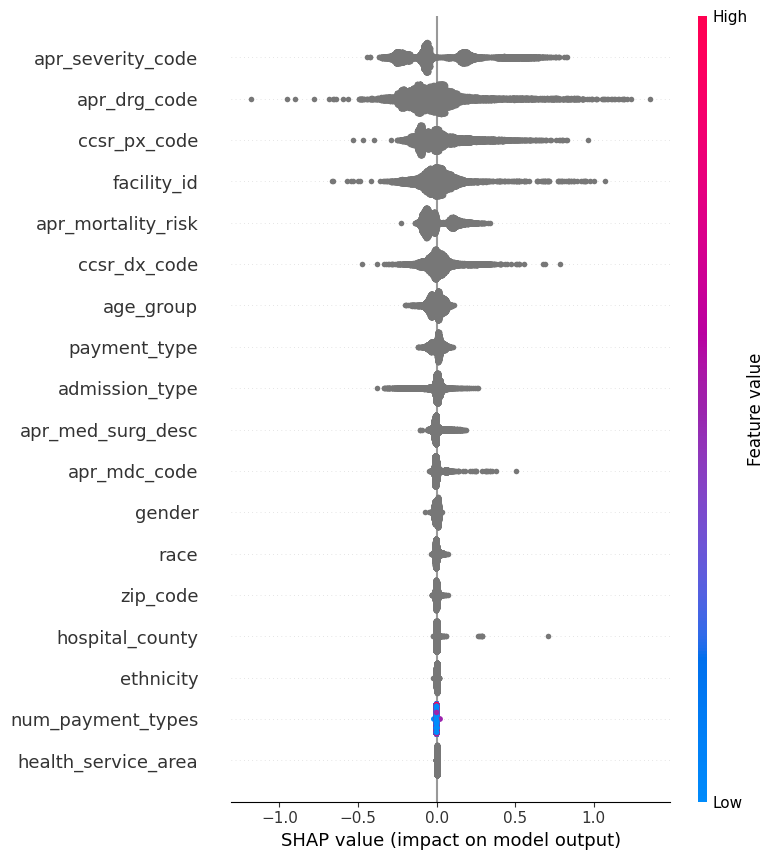

In [ ]:
import shap

#Sample size
sample_idx = np.random.choice(X.index, size=10000, replace=False)
X_sample = X.loc[sample_idx]

explainer = shap.TreeExplainer(loaded_model)
shap_values = explainer.shap_values(X_sample)

# Summary plot of how each feature affects model’s predictions
shap.summary_plot(shap_values, X_sample)

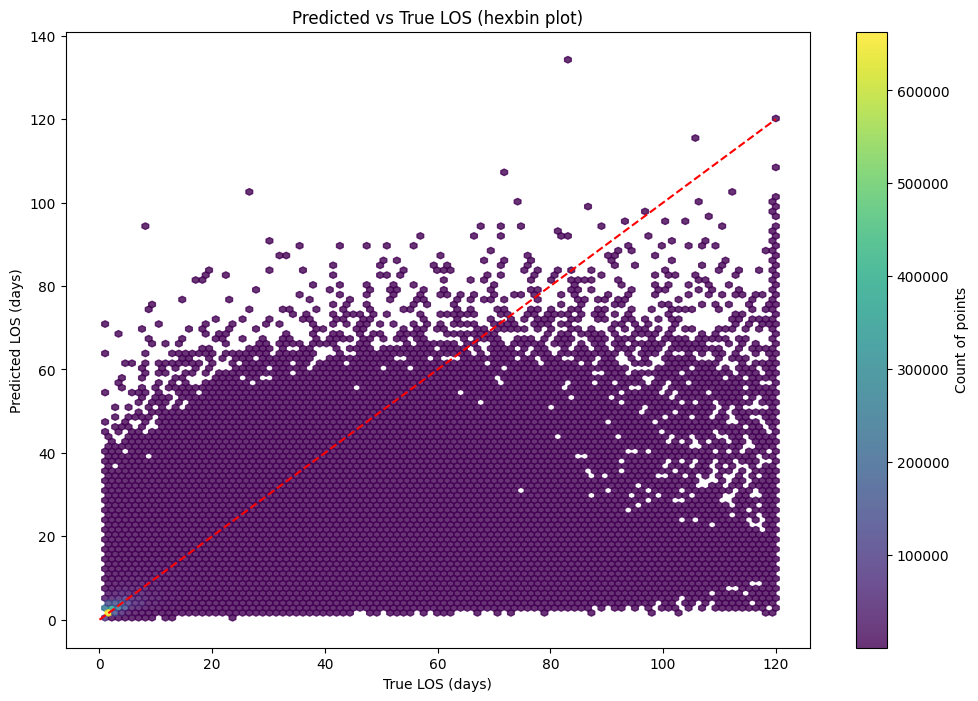

In [9]:
#Can see where the model over or under predicts LOS

import matplotlib.pyplot as plt

# True vs predicted LOS
y_true = data['length_of_stay'].values
y_pred_log = loaded_model.predict(X)
y_pred = np.expm1(y_pred_log)

plt.figure(figsize=(12, 8))

plt.hexbin(y_true, y_pred, gridsize=100, cmap='viridis', mincnt=1, alpha=0.8)
plt.plot([0, max(y_true)], [0, max(y_true)], color='red', linestyle='--')


plt.xlabel("True LOS (days)")
plt.ylabel("Predicted LOS (days)")
plt.title("Predicted vs True LOS (hexbin plot)")
cb = plt.colorbar()
cb.set_label('Count of points')
plt.show()
